# Classification Track — Review 1 (Part A)
**Dataset:** Airline Passenger Satisfaction  
**Target:** `satisfaction` (satisfied / neutral or dissatisfied)  
**Algorithms (Part A):** Logistic Regression, K-Nearest Neighbors, Gaussian Naive Bayes, Decision Tree, Support Vector Machine

This notebook covers: dataset audit, EDA, cleaning, feature engineering, encoding/scaling/splitting,
and training + evaluating the five Part-A classification algorithms with a comparison table.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_palette("colorblind")
plt.rcParams['figure.figsize'] = (8, 5)


## Section A — Dataset Audit & EDA

In [2]:
df = pd.read_csv("airlinepassenger.csv")
df = df.drop(columns=[c for c in ["Unnamed: 0", "id"] if c in df.columns])

print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum()[df.isna().sum() > 0])
print("\nTarget distribution:\n", df['satisfaction'].value_counts())
print("\nTarget distribution (%):\n", df['satisfaction'].value_counts(normalize=True) * 100)


Shape: (25976, 23)

Dtypes:
 Gender                                   str
Customer Type                            str
Age                                    int64
Type of Travel                           str
Class                                    str
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Inflight service                       int64
Cleanliness                            int64
Departure Delay in Minutes             int64
Arrival Delay in Minutes  

**Observation:** The dataset has 25,976 rows and 23 usable columns after dropping the two
identifier columns (`Unnamed: 0`, `id`), which carry no predictive signal and would only add noise
if left in. The only missing values are in `Arrival Delay in Minutes` (83 rows, ~0.3%). The target
classes are reasonably balanced (~55% neutral/dissatisfied vs ~45% satisfied), so no resampling is required.

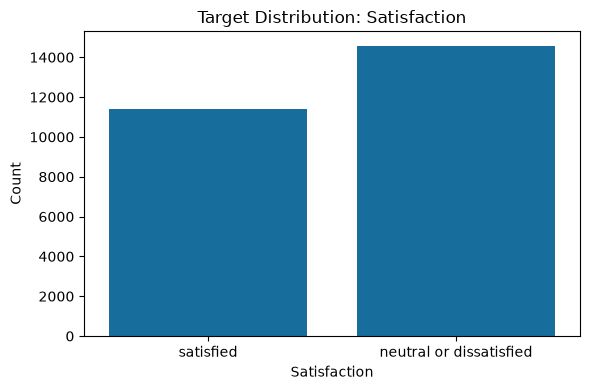

In [3]:
fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(data=df, x='satisfaction', ax=ax)
ax.set_title("Target Distribution: Satisfaction")
ax.set_xlabel("Satisfaction")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("target_distribution.png", bbox_inches="tight")
plt.show()


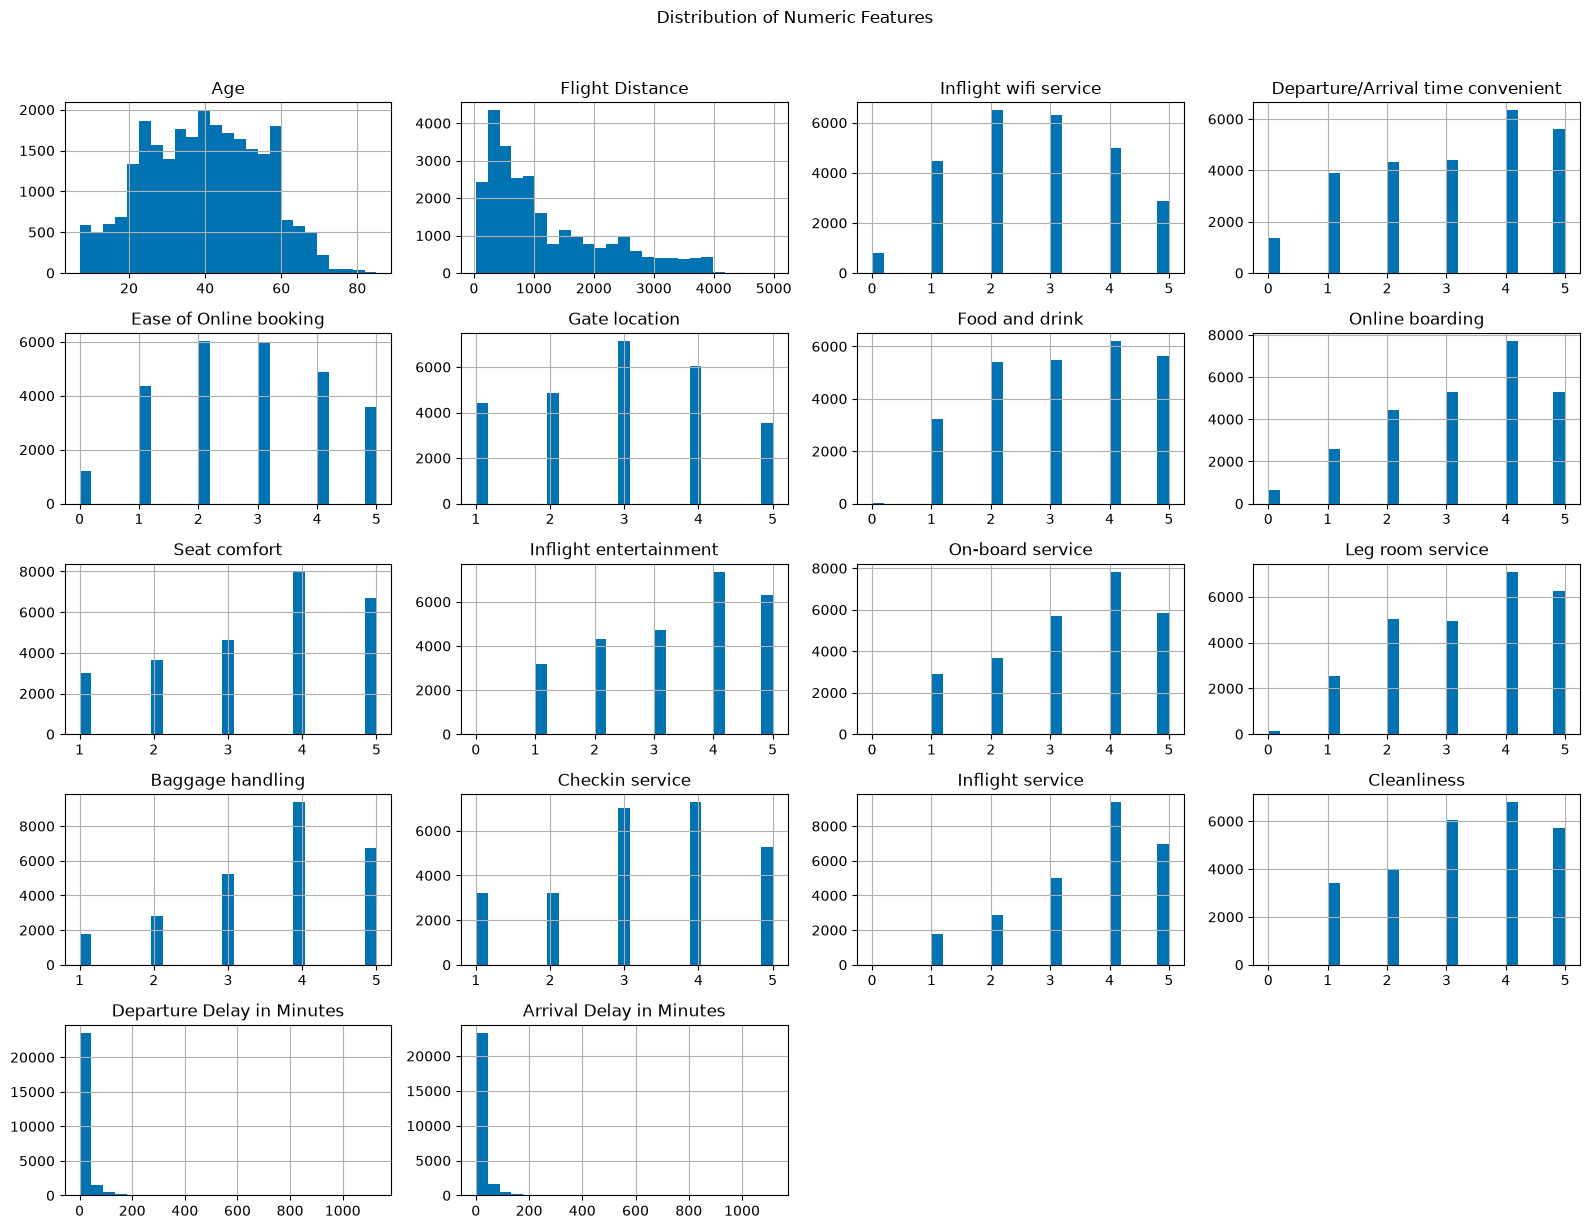

In [4]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[numeric_cols].hist(figsize=(16, 12), bins=25)
plt.suptitle("Distribution of Numeric Features", y=1.02)
plt.tight_layout()
plt.savefig("feature_distributions.png", bbox_inches="tight")
plt.show()


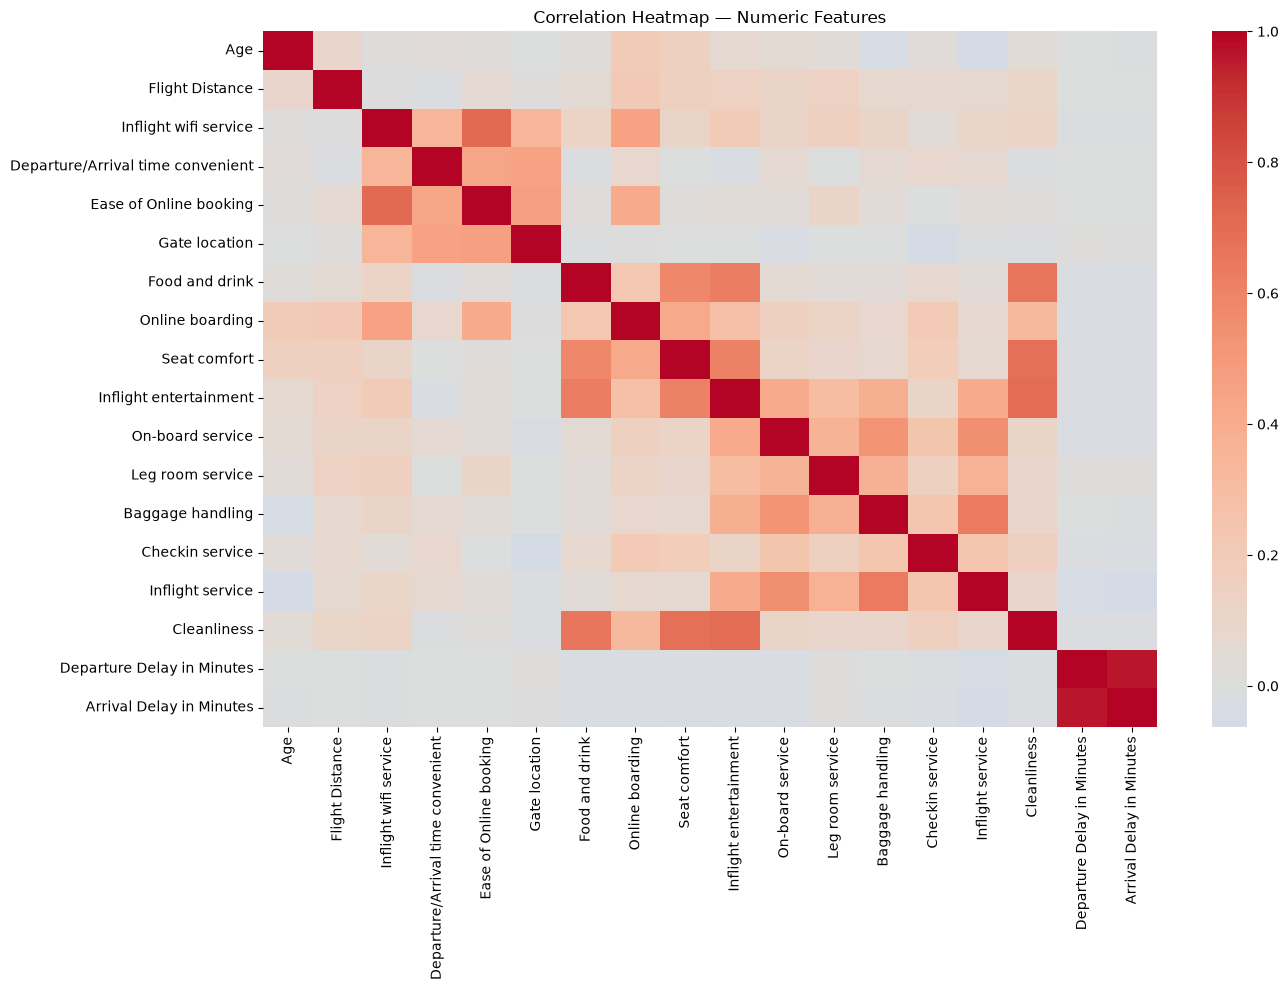

In [5]:
plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", bbox_inches="tight")
plt.show()


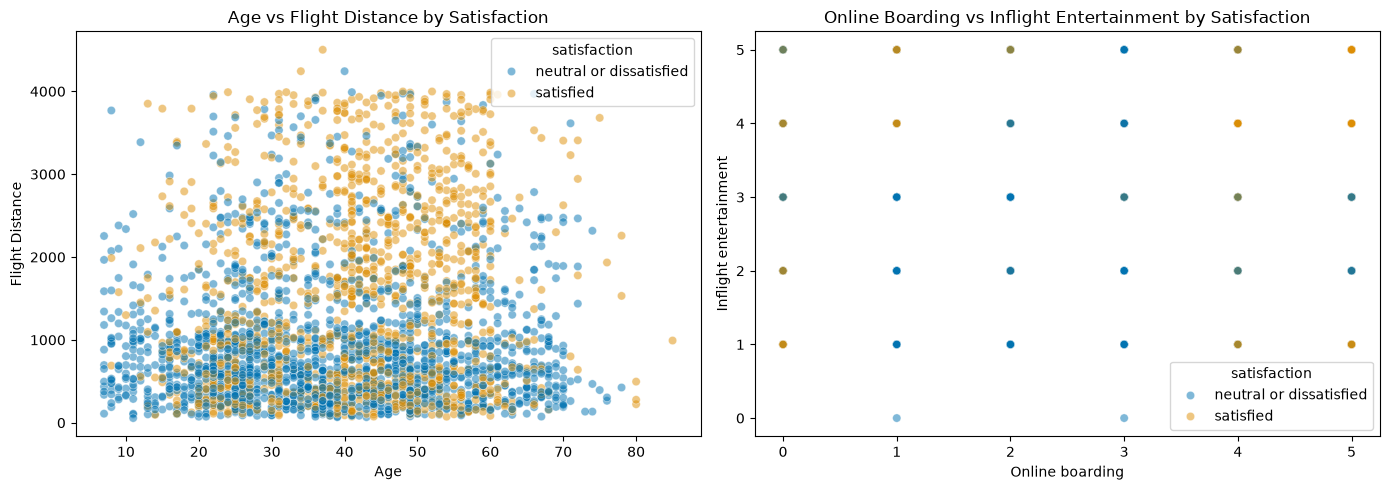

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df.sample(3000, random_state=RANDOM_STATE), x='Age', y='Flight Distance',
                 hue='satisfaction', alpha=0.5, ax=axes[0])
axes[0].set_title("Age vs Flight Distance by Satisfaction")

sns.scatterplot(data=df.sample(3000, random_state=RANDOM_STATE), x='Online boarding', y='Inflight entertainment',
                 hue='satisfaction', alpha=0.5, ax=axes[1])
axes[1].set_title("Online Boarding vs Inflight Entertainment by Satisfaction")
plt.tight_layout()
plt.savefig("scatter_relationships.png", bbox_inches="tight")
plt.show()


**Observations:**
- Numeric service-rating features (`Online boarding`, `Inflight entertainment`, `Seat comfort`) are
  ordinal (0–5) and show visibly higher scores associated with `satisfied` passengers in the scatter plots.
- `Departure Delay in Minutes` and `Arrival Delay in Minutes` are heavily right-skewed (most flights have
  little to no delay, with a long tail) — worth noting for outlier handling.
- The correlation heatmap shows `Departure Delay` and `Arrival Delay` are very highly correlated with
  each other (as expected, since one causes the other), which is useful to know before feature engineering.
